In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")        # ARIMA needs datetime index
df.head()


,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
timestamp,,,,,,
2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81
2015-01-01 02:00:00,8799.0,-0.4,95.0,-1.2,92.66,766.64
2015-01-01 03:00:00,8567.0,-0.6,95.0,-1.3,92.66,733.13


In [4]:
y = df["load_actual"]


In [5]:
train_size = int(len(y) * 0.8)

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]


In [6]:
order = (5,1,3)   # You can tune later if needed

arima = ARIMA(y_train, order=order)
arima_fit = arima.fit()
print(arima_fit.summary())


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not mo

                               SARIMAX Results                                
Dep. Variable:            load_actual   No. Observations:                70120
Model:                 ARIMA(5, 1, 3)   Log Likelihood             -493076.395
Date:                Mon, 24 Nov 2025   AIC                         986170.789
Time:                        21:27:33   BIC                         986253.211
Sample:                             0   HQIC                        986196.208
                              - 70120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5541      0.004    373.901      0.000       1.546       1.562
ar.L2         -1.5745      0.008   -207.779      0.000      -1.589      -1.560
ar.L3          1.4776      0.008    186.467      0.0

In [7]:
n_test = len(y_test)
pred_arima = arima_fit.forecast(steps=n_test)
pred_arima = np.array(pred_arima)


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [11]:
mae_arima = mean_absolute_error(y_test, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))
mape_arima = np.mean(np.abs((y_test - pred_arima) / y_test)) * 100

print("ARIMA Results:")
print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)


ARIMA Results:
MAE: 1174.0480905158906
RMSE: 1430.2471389648913
MAPE: 12.855821046740811


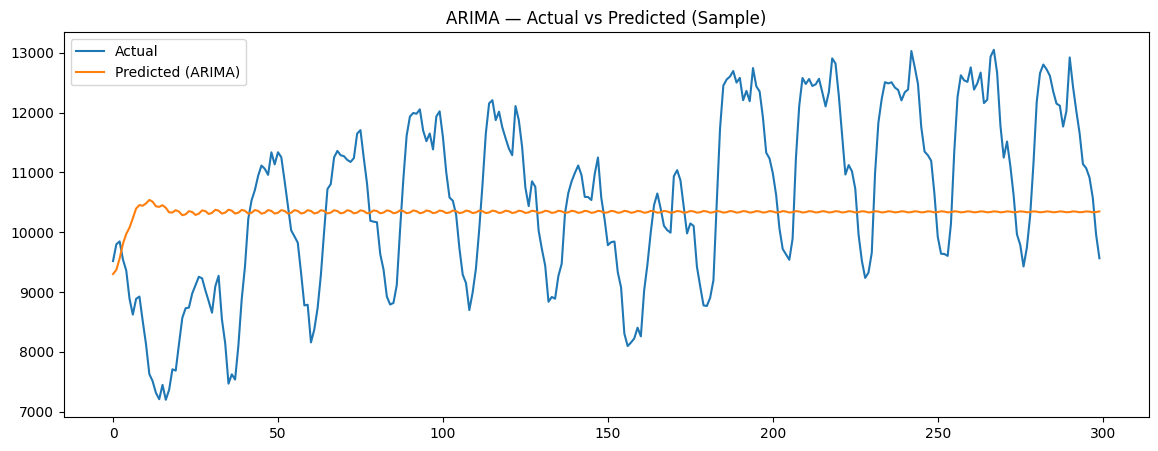

In [12]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred_arima[:300], label="Predicted (ARIMA)")
plt.legend()
plt.title("ARIMA — Actual vs Predicted (Sample)")
plt.show()


In [13]:
arima_fit.save("../saved_models/arima_model.pkl")